# $gg (\to h^{\ast}) \to ZZ$ sample reweighting, $c_6$-modification, and analytical density ratios

In [1]:
import sys
sys.path.insert(1, '..')

import hist
import numpy as np
import matplotlib.pyplot as plt

from physics.hstar import c6
from physics.hzz import zpair, zz4l
from physics.simulation import sample as s, msq

import importlib

## The "Baseline" sample

The baseline sample consists of events from 3 channels:
- $4\ell$,
- $4\mu$, and
- $2\ell 2\mu$,
where interference effects between the identical final state particles in the first 2 channels must be (and have been) taken into account.


$$ |\mathcal{M}|^2 =  $$

In [2]:
sample = s.from_csv(1.5, file_path='../../ggZZ2e2m_sbi.csv', n_rows=100000)

0.5379746106337265


In [3]:
z_cand = zpair.ZPairCandidate(algorithm='truth')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
four_lepton = zz4l.FourLeptonSystem()
angles = zz4l.AngularVariables()

sample = sample.calculate(z_cand).filter(z_masses).calculate(four_lepton).calculate(angles)

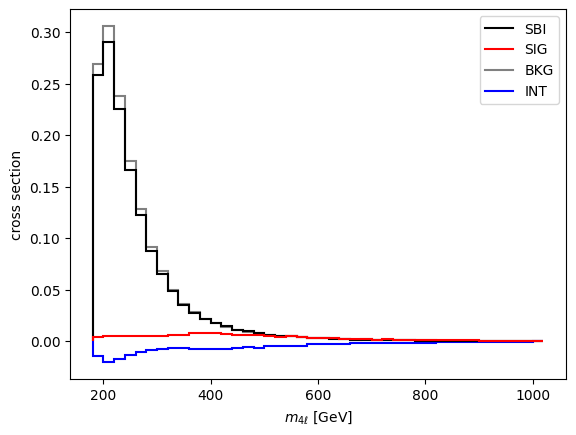

In [4]:
m4l = sample.kinematics[['4l_mass']].to_numpy().flatten()

BINS = 42
bounds = [180,1020]

wt_sbi = sample.weights
wt_sig = sample.reweight(msq.Component.SBI, msq.Component.SIG).weights
wt_int = sample.reweight(msq.Component.SBI, msq.Component.INT).weights
wt_bkg = sample.reweight(msq.Component.SBI, msq.Component.BKG).weights

h_m4l_sbi = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_m4l_sbi.fill(m4l, weight=wt_sbi)

h_m4l_sig = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_m4l_sig.fill(m4l, weight=wt_sig)

h_m4l_int = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_m4l_int.fill(m4l, weight=wt_int)

h_m4l_bkg = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_m4l_bkg.fill(m4l, weight=wt_bkg)

h_m4l_sbi.plot(color='black', label='SBI', zorder=9)
h_m4l_sig.plot(color='red', label='SIG', zorder=10)
h_m4l_bkg.plot(color='grey', label='BKG', zorder=7)
h_m4l_int.plot(color='blue', label='INT', zorder=8)

plt.xlabel('$m_{4\ell}$ [GeV]')
plt.ylabel('cross section')

plt.legend()

plt.show()

## $c_6$ morphing

The SM amplitudes can be obtained by the reweightin procedure above.

The order of polynomial dependence of each amplitude component is as follows:
- $$f_{\mathrm{sig}}(c_6) = f^{(4)}(c_6) = a + b c_6 + d c_6^2 + e c_6^3 + f c_6^4$$
- $$b$$

Since the morphing is specific to the amplitude component, a modifier class dedicated to each should be configured.
In addition, it determines how many unique $c_6$ coordinates and their correspondingly-modified amplitudes are required to fully solve the polynomial dependence.

In [5]:
c6mod_sbi = c6.Modifier( msq.Component.SBI, sample, c6_values = [-5, -1, 0, 1, 5] )
c6mod_sig = c6.Modifier( msq.Component.SIG, sample.reweight(msq.Component.SBI, msq.Component.SIG), c6_values = [-5, -1, 0, 1, 5])
c6mod_bkg = c6.Modifier( msq.Component.BKG, sample.reweight(msq.Component.SBI, msq.Component.BKG), c6_values = [-10, 0, 10])
c6mod_int = c6.Modifier( msq.Component.INT, sample.reweight(msq.Component.SBI, msq.Component.INT), c6_values = [ -5, 0,  5])

/home/max/Uni/WS24/BachelorArbeit/higgs-offshell-interpretation/notebooks/../physics/hstar/c6.py:18: RuntimeWarning: invalid value encountered in divide
  self.coefficients = np.apply_along_axis(lambda x: np.linalg.solve(np.vander(self.c6_values, len(self.c6_values), increasing=True), x), 1, msq_c6 / msq_sm[:, np.newaxis])


Then, the varied weights of the events can be obtained by calling on `modify()` on the appropriate sample and the desired value(s) of $c_6$.

In [6]:
# over many values of c6
c6_values = np.linspace(-10.0,10.0,101)

# for each amplitude component
c6wt_sbi, c6pb_sbi = c6mod_sbi.modify(c6_values)
c6wt_sig, c6pb_sig = c6mod_sig.modify(c6_values)
c6wt_bkg, c6pb_bkg = c6mod_bkg.modify(c6_values)
c6wt_int, c6pb_int = c6mod_int.modify(c6_values)

### Closure check of morphing

As a self-closure check, the morphed event weight at any $c_6$ value (i.e. evaluated from the polynomial dependence) should correspond with the correct (i.e. as actually evaluted by MCFM).

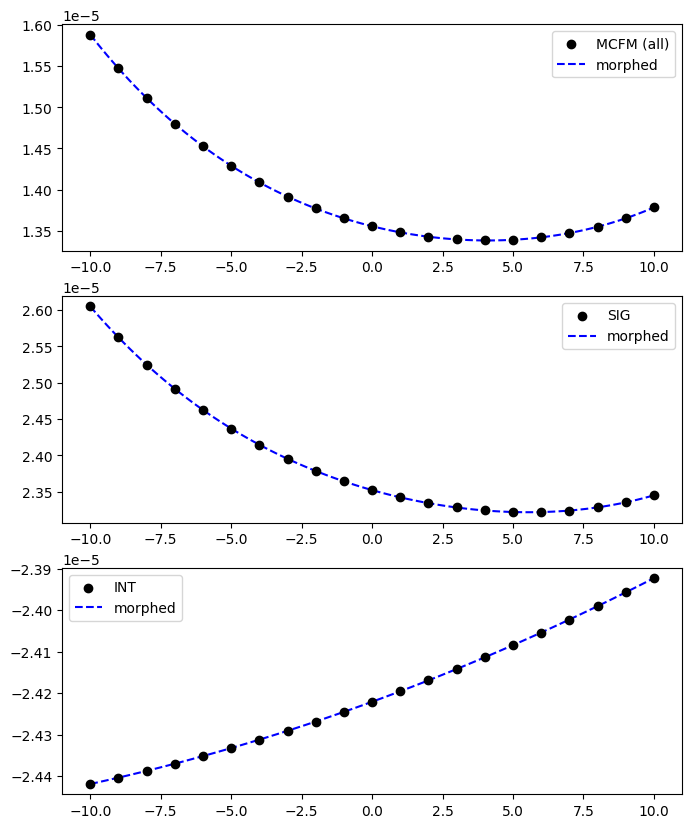

In [7]:
# let's look a specific event
random_event_index = 13274

c6_points = np.linspace(-10,10,21)

wt_points_sbi = [sample.weights[random_event_index] * sample.components[f'msq_sbi_c6_{i}'][random_event_index]/sample.components[f'msq_sbi_sm'][random_event_index] for i in range(1,22)]
wt_points_sig = [sample.reweight(msq.Component.SBI, msq.Component.SIG).weights[random_event_index] * sample.components[f'msq_sig_c6_{i}'][random_event_index]/sample.components[f'msq_sig_sm'][random_event_index] for i in range(1,22)]
wt_points_int = [sample.reweight(msq.Component.SBI, msq.Component.INT).weights[random_event_index] * sample.components[f'msq_int_c6_{i}'][random_event_index]/sample.components[f'msq_int_sm'][random_event_index] for i in range(1,22)]

wt_curve_sbi = c6wt_sbi[random_event_index]
wt_curve_sig = c6wt_sig[random_event_index]
wt_curve_int = c6wt_int[random_event_index]

fig, (ax_sbi ,ax_sig, ax_int) = plt.subplots(3, 1, figsize=(8, 10))

ax_sbi.scatter(c6_points, wt_points_sbi, marker='o', color='black', label='MCFM (all)', zorder=10)
ax_sbi.plot(c6_values, wt_curve_sbi, color='blue', linestyle='--', label='morphed')

ax_sbi.legend()

ax_sig.scatter(c6_points, wt_points_sig, marker='o', color='black', label='SIG', zorder=10)
ax_sig.plot(c6_values, wt_curve_sig, color='blue', linestyle='--', label='morphed')

ax_sig.legend()

ax_int.scatter(c6_points, wt_points_int, marker='o', color='black', label='INT', zorder=10)
ax_int.plot(c6_values, wt_curve_int, color='blue', linestyle='--', label='morphed')

ax_int.legend()